In [1]:
! py -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
! py -m pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Preprocessing 

In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.shape

(7043, 21)

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [16]:
df["TotalCharges"].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [19]:
df = df.dropna()

In [20]:
df.shape

(7032, 21)

In [21]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [22]:
df = df.drop("customerID",axis=1)

In [24]:
df.shape

(7032, 20)

In [25]:
df.columns 

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [28]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [29]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [31]:
import warnings
warnings.filterwarnings("ignore")
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [32]:
df = pd.get_dummies(df, drop_first=True)

In [33]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [34]:
df.shape

(7032, 31)

# Training the model

In [35]:
x = df.drop("Churn",axis=1)
y = df["Churn"]

In [36]:
print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (7032, 30)
Y shape: (7032,)


In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print("X_train:",x_train.shape)
print("X_test:",x_test.shape)
print("Y_train:",y_train.shape)
print("Y_test:",y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
Y_train: (5625,)
Y_test: (1407,)


# Logistic Regression 

In [39]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


# Accuracy Score 

In [40]:
from sklearn.metrics import accuracy_score 
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7874911158493249


# Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[915 118]
 [181 193]]


# Classification Report

In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# Confusion Matrix-Display

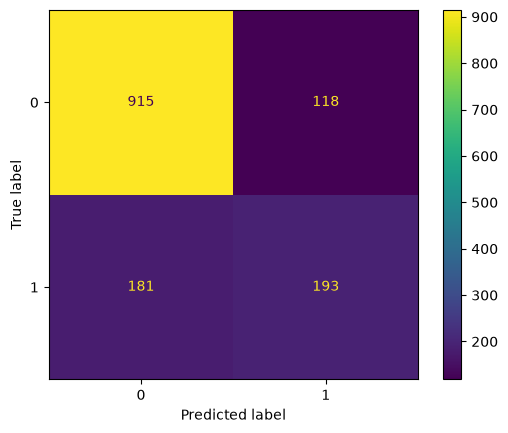

In [43]:
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

# Decision Trees

In [44]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)
dt_pred = dt_model.predict(x_test)

# Accuarcy Score 

In [45]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test,dt_pred)
print("DecisionTreeClassifier Accuracy:",dt_accuracy)

DecisionTreeClassifier Accuracy: 0.7249466950959488


# Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, dt_pred)
print(cm)

[[825 208]
 [179 195]]


# Confusion Matrix - display

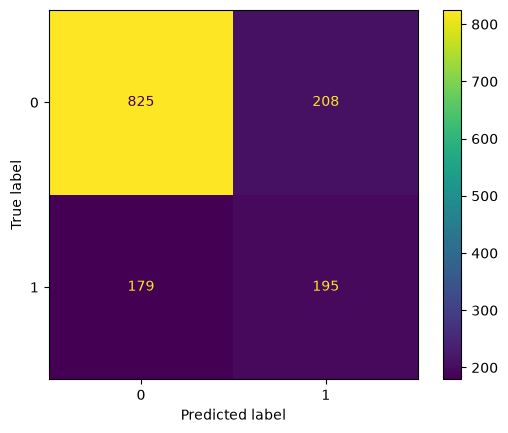

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt 
ConfusionMatrixDisplay.from_predictions(y_test,dt_pred)
plt.show()

# RandomForestClassifier with accuarcyscore , confusion matrix , showing confusion matrix with graphical represntation

Random Forest Classifier accuracy: 0.7853589196872779
[[927 106]
 [196 178]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



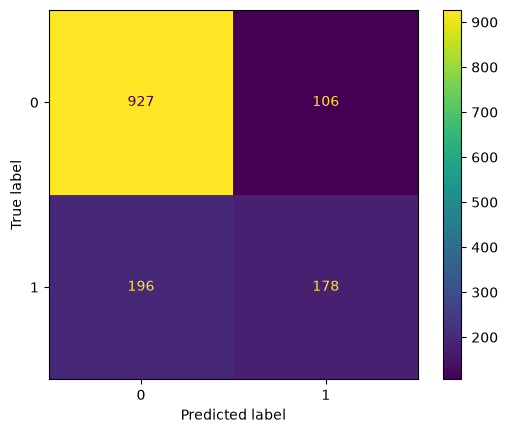

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)
rf_model.fit(x_train,y_train)
rf_pred = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test,rf_pred)
print("Random Forest Classifier accuracy:",rf_accuracy)
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test,rf_pred))
ConfusionMatrixDisplay.from_predictions (y_test,rf_pred)
plt.show()

# Save the model in the form of pkl

In [49]:
import joblib
joblib.dump(model,"churn_model.pkl")

['churn_model.pkl']

In [50]:
import os
print(os.listdir())

['churn.ipynb', 'churn_model.pkl', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [51]:
print(x.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [52]:
x.columns.tolist()

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [53]:
import joblib 
joblib.dump(x.columns.tolist(),"feature_names.pkl")


['feature_names.pkl']

# Accuracy Comparison Bar Graph

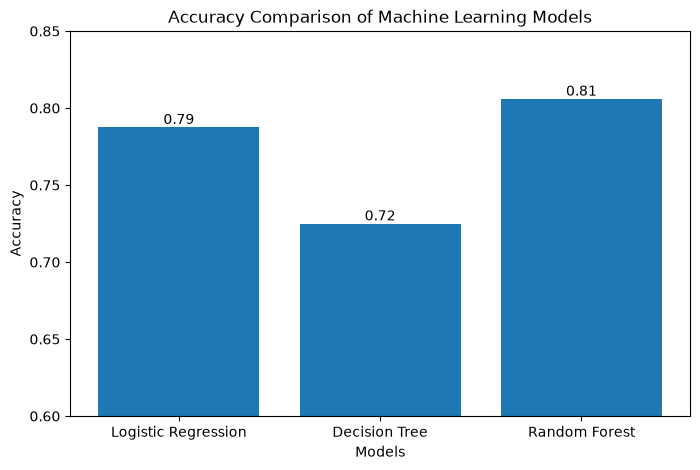

In [15]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracies = [0.7875, 0.7249, 0.8059]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.6, 0.85)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha="center",
             va="bottom",
             fontsize=10)

plt.show()

# graphical represntation of decision tree

Accuracy: 0.7249466950959488
[[825 208]
 [179 195]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407



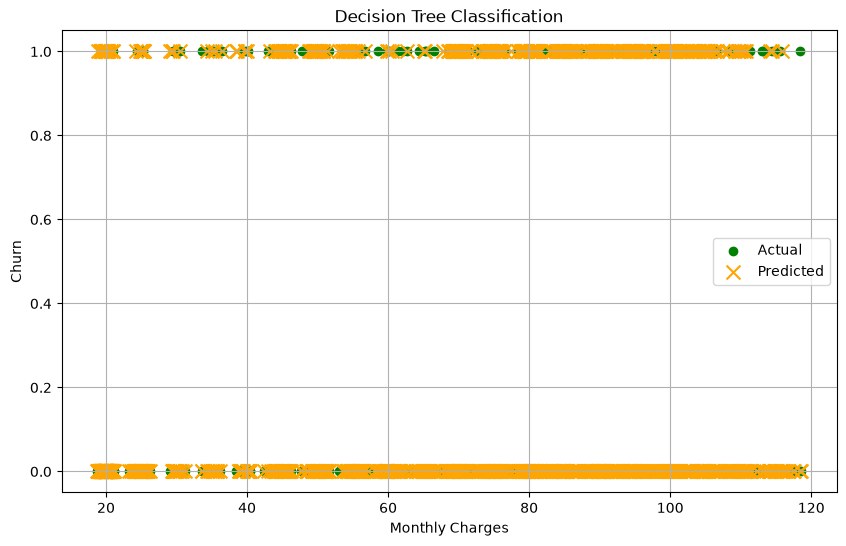

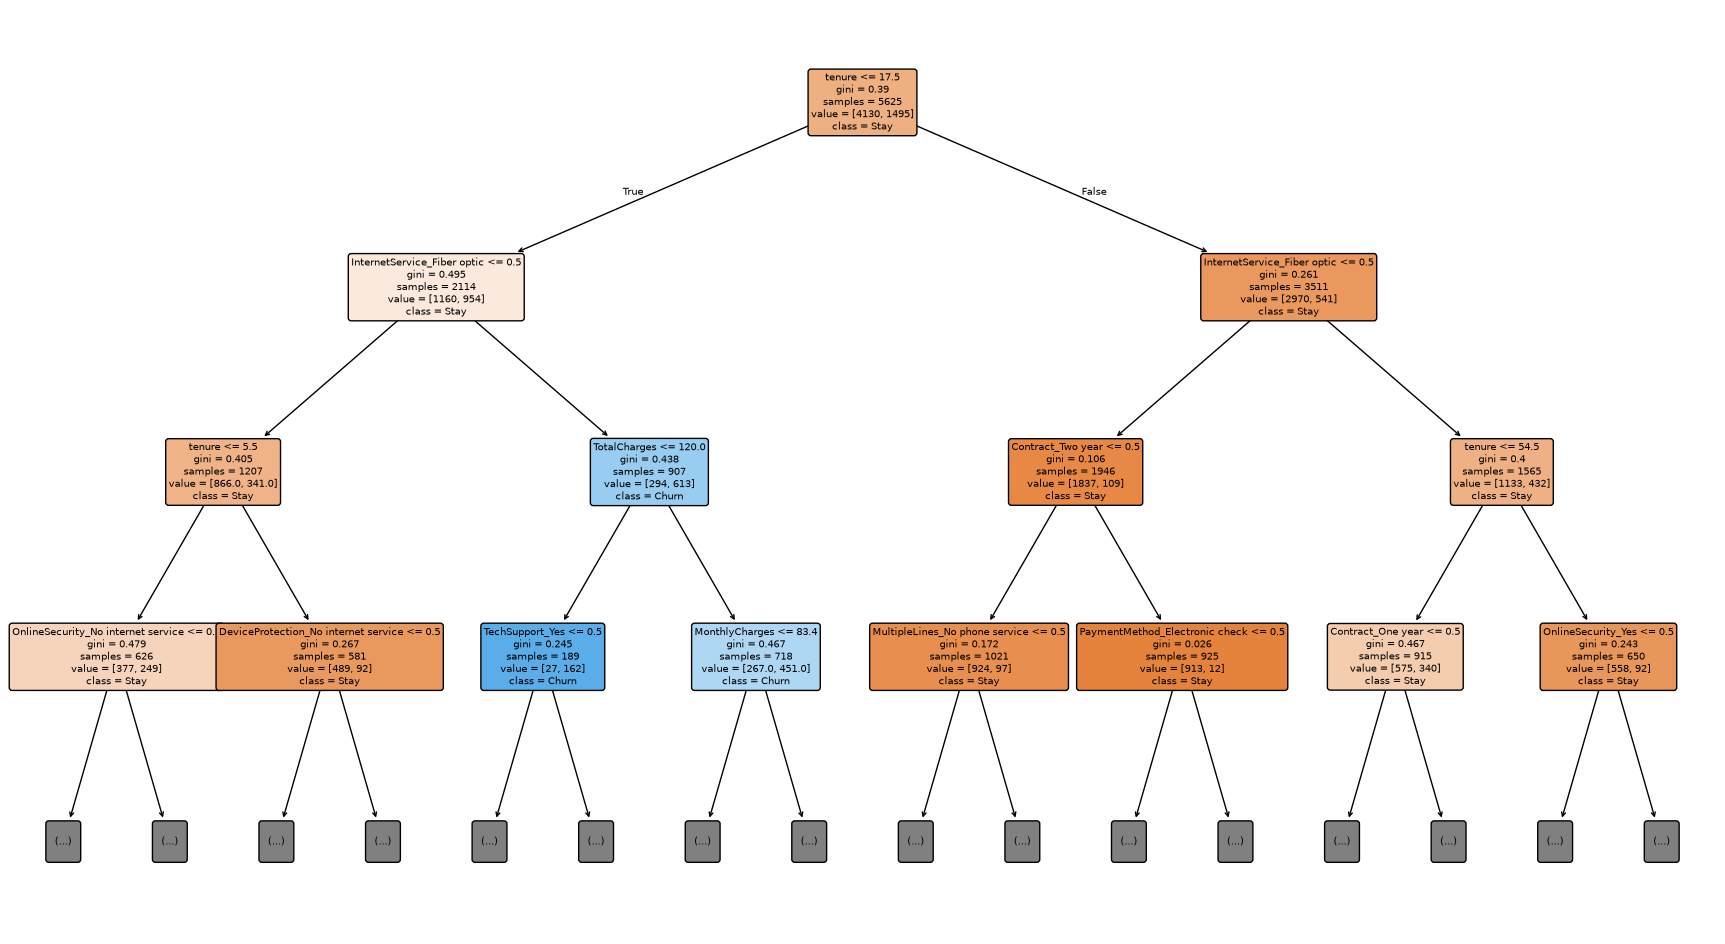

In [ ]:
# DECISION TREE CLASSIFICATION

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Data Preprocessing
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = DecisionTreeClassifier(random_state=42)``

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

# Graphical Representation
plt.figure(figsize=(10,6))

plt.scatter(
    X_test["MonthlyCharges"],
    y_test,
    color="green",
    label="Actual"
)

plt.scatter(
    X_test["MonthlyCharges"],
    y_pred,
    color="orange",
    marker="x",
    s=100,
    label="Predicted"
)

plt.title("Decision Tree Classification")

plt.xlabel("Monthly Charges")

plt.ylabel("Churn")

plt.legend()

plt.grid(True)

plt.show()

# Decision Tree Diagram
plt.figure(figsize=(22,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Stay","Churn"],
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3
)

plt.show()

# graphical representation of logistic regression 

Accuracy: 0.7874911158493249
[[915 118]
 [181 193]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



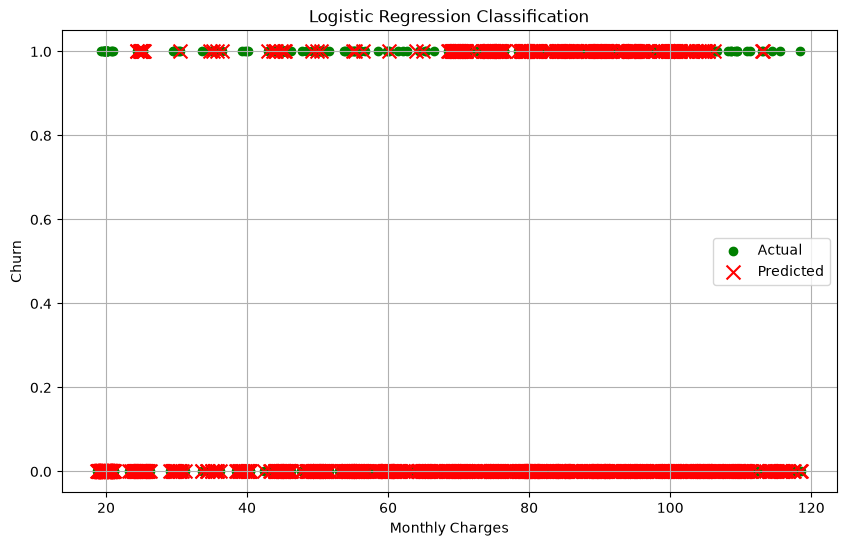

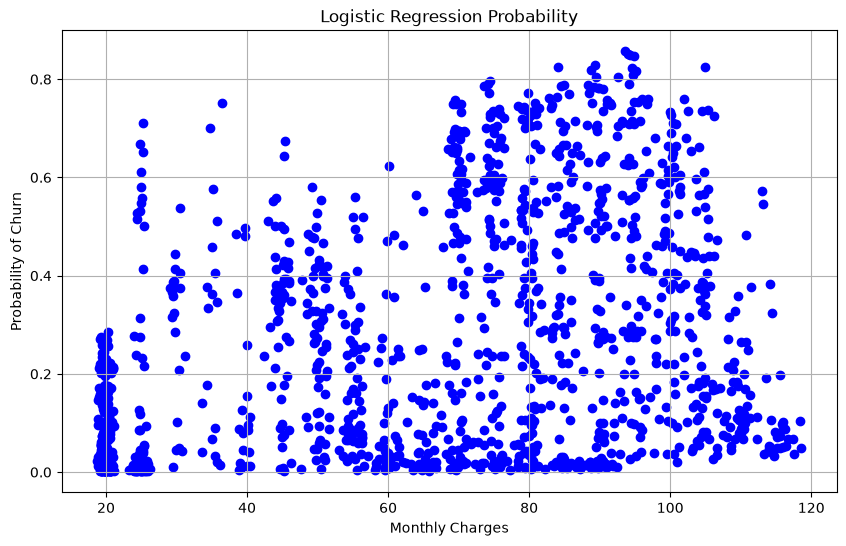

In [3]:
# LOGISTIC REGRESSION

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Data Preprocessing
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Save original X_test for graphs
X_test_original = X_test.copy()

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

# Graphical Representation
plt.figure(figsize=(10,6))

plt.scatter(
    X_test_original["MonthlyCharges"],
    y_test,
    color="green",
    label="Actual"
)

plt.scatter(
    X_test_original["MonthlyCharges"],
    y_pred,
    color="red",
    marker="x",
    s=100,
    label="Predicted"
)

plt.title("Logistic Regression Classification")

plt.xlabel("Monthly Charges")

plt.ylabel("Churn")

plt.legend()

plt.grid(True)

plt.show()

# Probability Graph
probability = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(10,6))

plt.scatter(
    X_test_original["MonthlyCharges"],
    probability,
    color="blue"
)

plt.title("Logistic Regression Probability")

plt.xlabel("Monthly Charges")

plt.ylabel("Probability of Churn")

plt.grid(True)

plt.show()

# graphical representation of randomforestclassifier

Accuracy: 0.8059701492537313
[[947  86]
 [187 187]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1033
           1       0.68      0.50      0.58       374

    accuracy                           0.81      1407
   macro avg       0.76      0.71      0.73      1407
weighted avg       0.80      0.81      0.80      1407



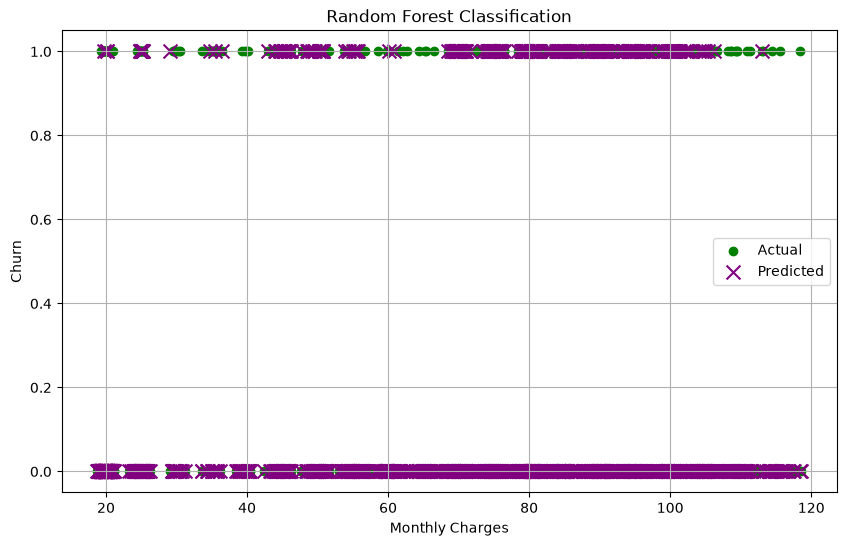

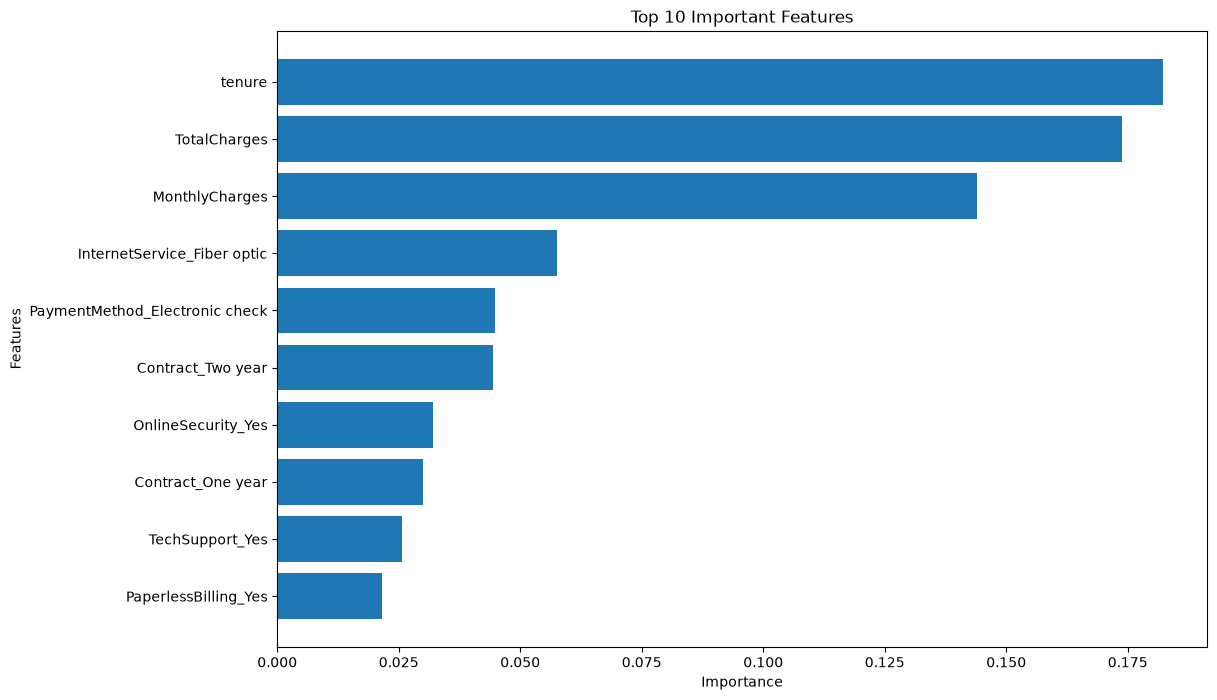

In [20]:
# randomforestclassifier
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Data Preprocessing
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

# Graphical Representation
plt.figure(figsize=(10,6))

plt.scatter(
    X_test["MonthlyCharges"],
    y_test,
    color="green",
    label="Actual"
)

plt.scatter(
    X_test["MonthlyCharges"],
    y_pred,
    color="purple",
    marker="x",
    s=100,
    label="Predicted"
)

plt.title("Random Forest Classification")

plt.xlabel("Monthly Charges")

plt.ylabel("Churn")

plt.legend()

plt.grid(True)

plt.show()

# Feature Importance Graph

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [5]:
! py -m pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 262.1 kB/s eta 0:03:05
   ---------------------------------------- 0.5/48.9 MB 262.1 kB/s eta 0:03:05
  


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# XGBOOST model prediction

XGBoost Accuracy: 0.7903340440653873
[[914 119]
 [176 198]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



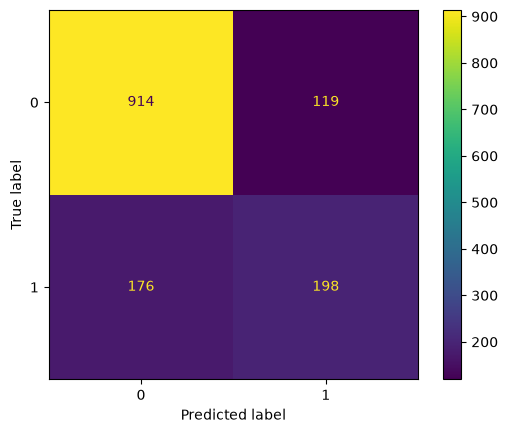

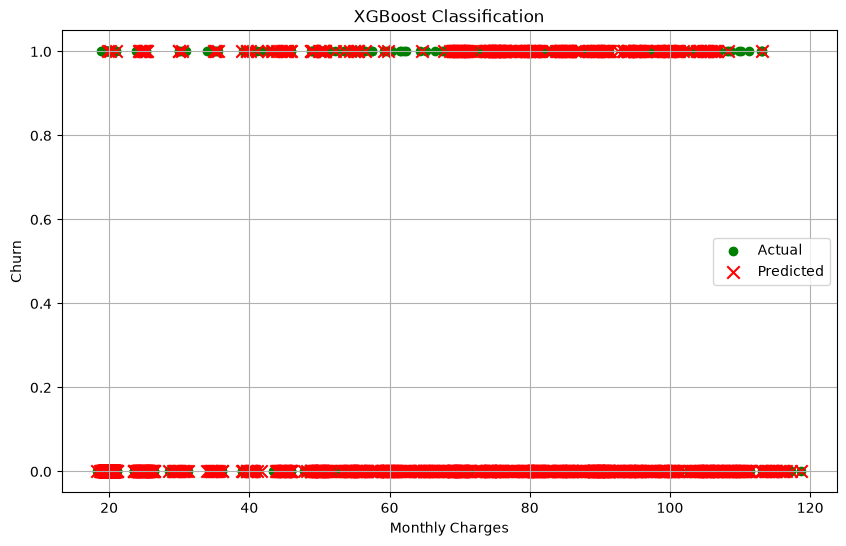

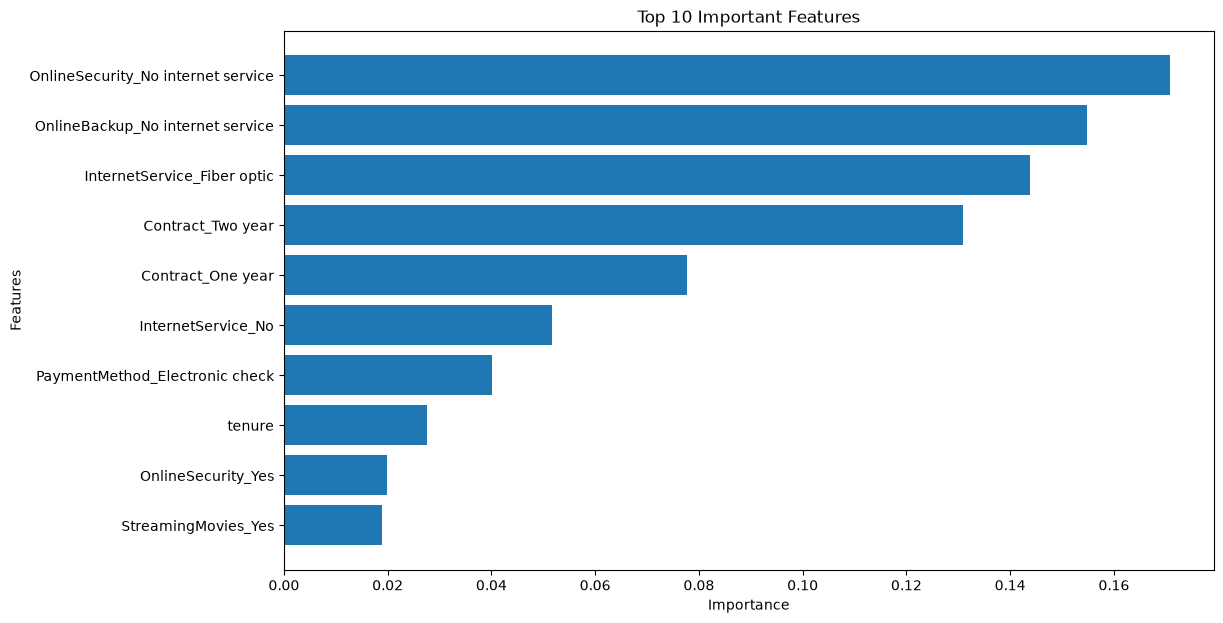

In [18]:
# XGBOOST CLASSIFICATION

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Data Preprocessing
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost Model
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix Graph
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

# Actual vs Predicted Graph
plt.figure(figsize=(10,6))

plt.scatter(
    X_test["MonthlyCharges"],
    y_test,
    color="green",
    label="Actual"
)

plt.scatter(
    X_test["MonthlyCharges"],
    y_pred,
    color="red",
    marker="x",
    s=80,
    label="Predicted"
)

plt.title("XGBoost Classification")

plt.xlabel("Monthly Charges")

plt.ylabel("Churn")

plt.legend()

plt.grid(True)

plt.show()

# Feature Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,7))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

# comparison of four models 

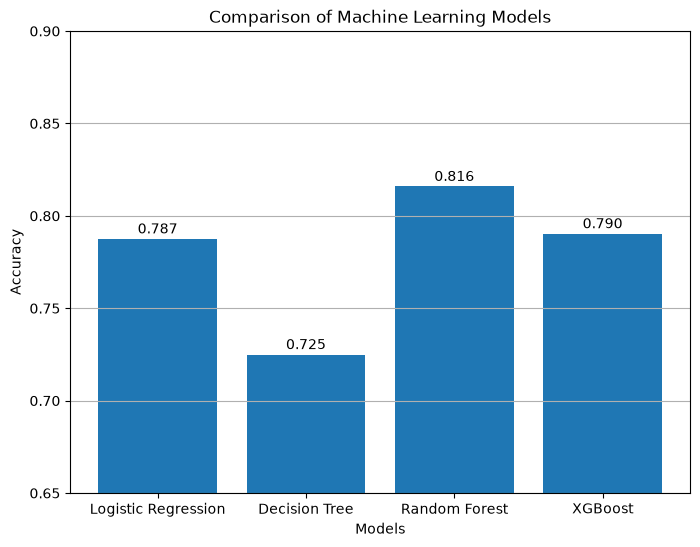

In [24]:
import matplotlib.pyplot as plt

# Model Names
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

# Model Accuracies
accuracies = [
    0.7875,   # Logistic Regression
    0.7249,   # Decision Tree
    0.8159,   # Random Forest
    0.7903   # XGBoost 
]

plt.figure(figsize=(8,6))

bars = plt.bar(models, accuracies)

# Display accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.65, 0.90)

plt.grid(axis="y")

plt.show()